# NASA POWER Weather Analysis for Zip Code 94514

This notebook analyzes NASA POWER weather data for Discovery Bay, California (zip code 94514). We'll load the data, process it, create visualizations, and identify climate anomalies.

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import os

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## Load NASA POWER Weather Data

Load the pre-downloaded NASA POWER weather data from the data/weather/ directory for the specified zip code area.

In [2]:
# Load the weather data
data_path = '/workspaces/agent-project/data/weather/weather_2019_2022.json'

with open(data_path, 'r') as f:
    data = json.load(f)

# Extract the parameter data
weather_data = data['properties']['parameter']

# Convert to DataFrame
df = pd.DataFrame({
    'date': list(weather_data['T2M_MAX'].keys()),
    'tmax': list(weather_data['T2M_MAX'].values()),
    'tmin': list(weather_data['T2M_MIN'].values()),
    'precip': list(weather_data['PRECTOTCORR'].values())
})

print(f"Loaded {len(df)} days of weather data")
print(df.head())

Loaded 1461 days of weather data
       date   tmax  tmin  precip
0  20190101  11.19 -2.00    0.00
1  20190102  11.59 -0.38    0.00
2  20190103  11.18  1.55    0.00
3  20190104  14.08  2.50    0.00
4  20190105  13.34  5.67    9.29


## Process Date Column and Filter to Growing Season

Convert the date column to datetime format and filter the data to the most recent growing season (April-October for California).

In [3]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

# Set date as index
df.set_index('date', inplace=True)

# Filter to most recent growing season (April-October 2022)
growing_season_2022 = df[(df.index >= '2022-04-01') & (df.index <= '2022-10-31')]

print(f"Growing season data: {len(growing_season_2022)} days")
print(growing_season_2022.head())

Growing season data: 214 days
             tmax  tmin  precip
date                           
2022-04-01  22.23  6.90    0.00
2022-04-02  23.47  6.83    0.00
2022-04-03  23.76  7.16    0.00
2022-04-04  20.65  7.51    0.11
2022-04-05  21.63  6.37    0.01


## Time-Series Visualization of Temperature and Precipitation

Create a time-series plot displaying daily high/low temperatures and precipitation.

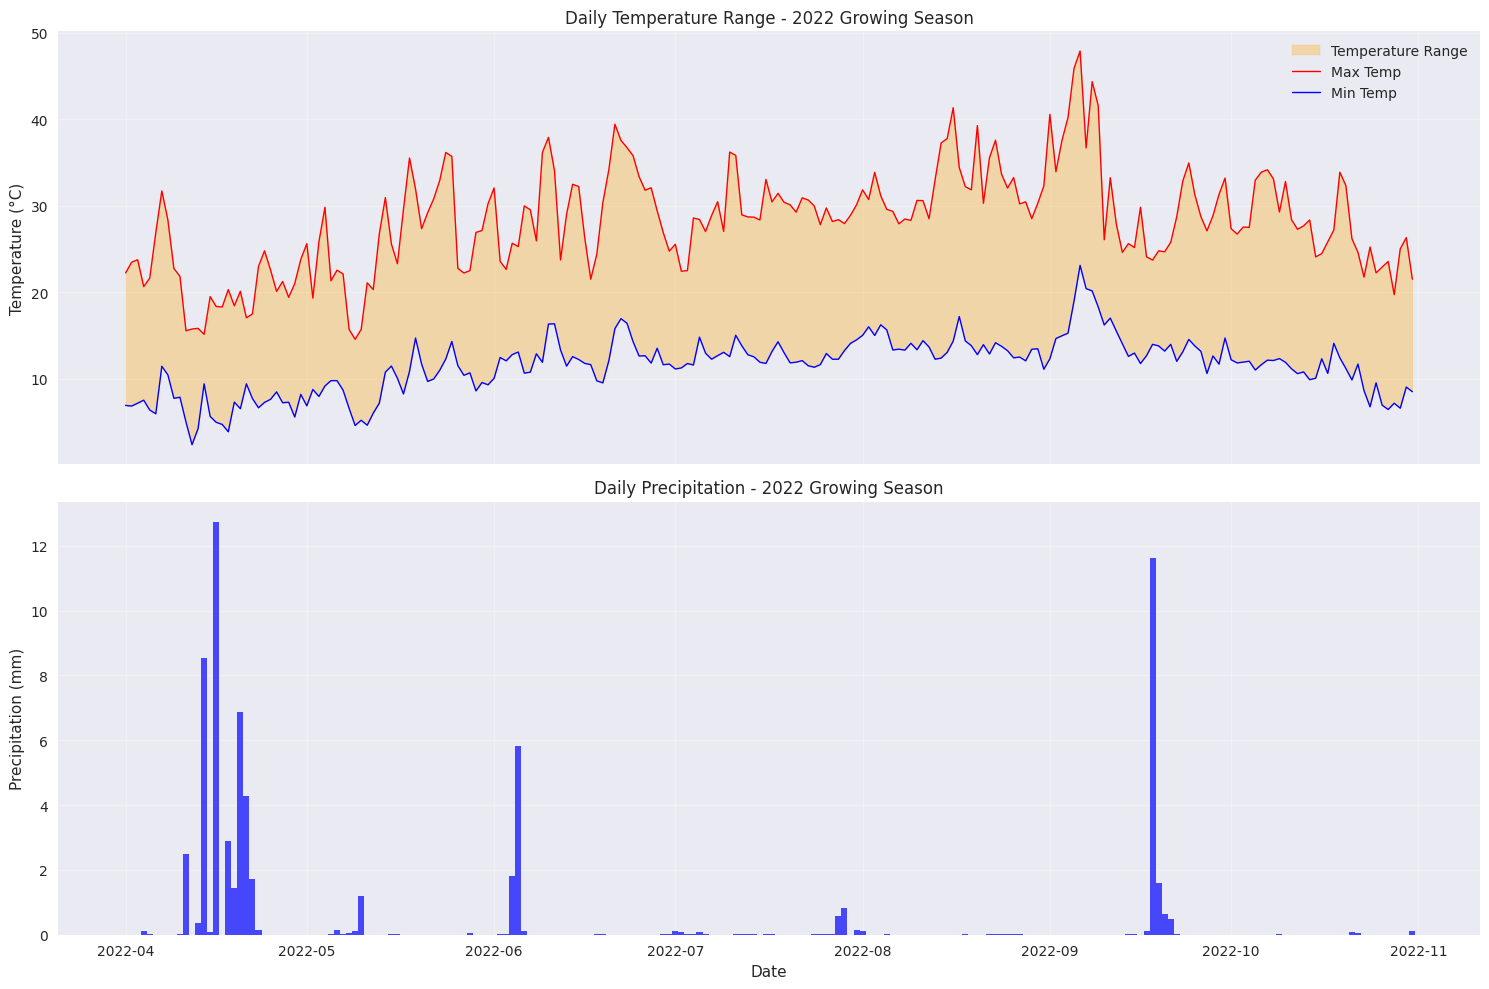

In [4]:
# Create time-series visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Temperature plot
ax1.fill_between(growing_season_2022.index, growing_season_2022['tmin'], growing_season_2022['tmax'], 
                 alpha=0.3, color='orange', label='Temperature Range')
ax1.plot(growing_season_2022.index, growing_season_2022['tmax'], color='red', linewidth=1, label='Max Temp')
ax1.plot(growing_season_2022.index, growing_season_2022['tmin'], color='blue', linewidth=1, label='Min Temp')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Daily Temperature Range - 2022 Growing Season')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Precipitation plot
ax2.bar(growing_season_2022.index, growing_season_2022['precip'], color='blue', alpha=0.7, width=1)
ax2.set_ylabel('Precipitation (mm)')
ax2.set_title('Daily Precipitation - 2022 Growing Season')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Calculate Rolling Averages

Compute 7-day and 30-day rolling averages for temperature and precipitation to smooth the data and highlight seasonal trends.

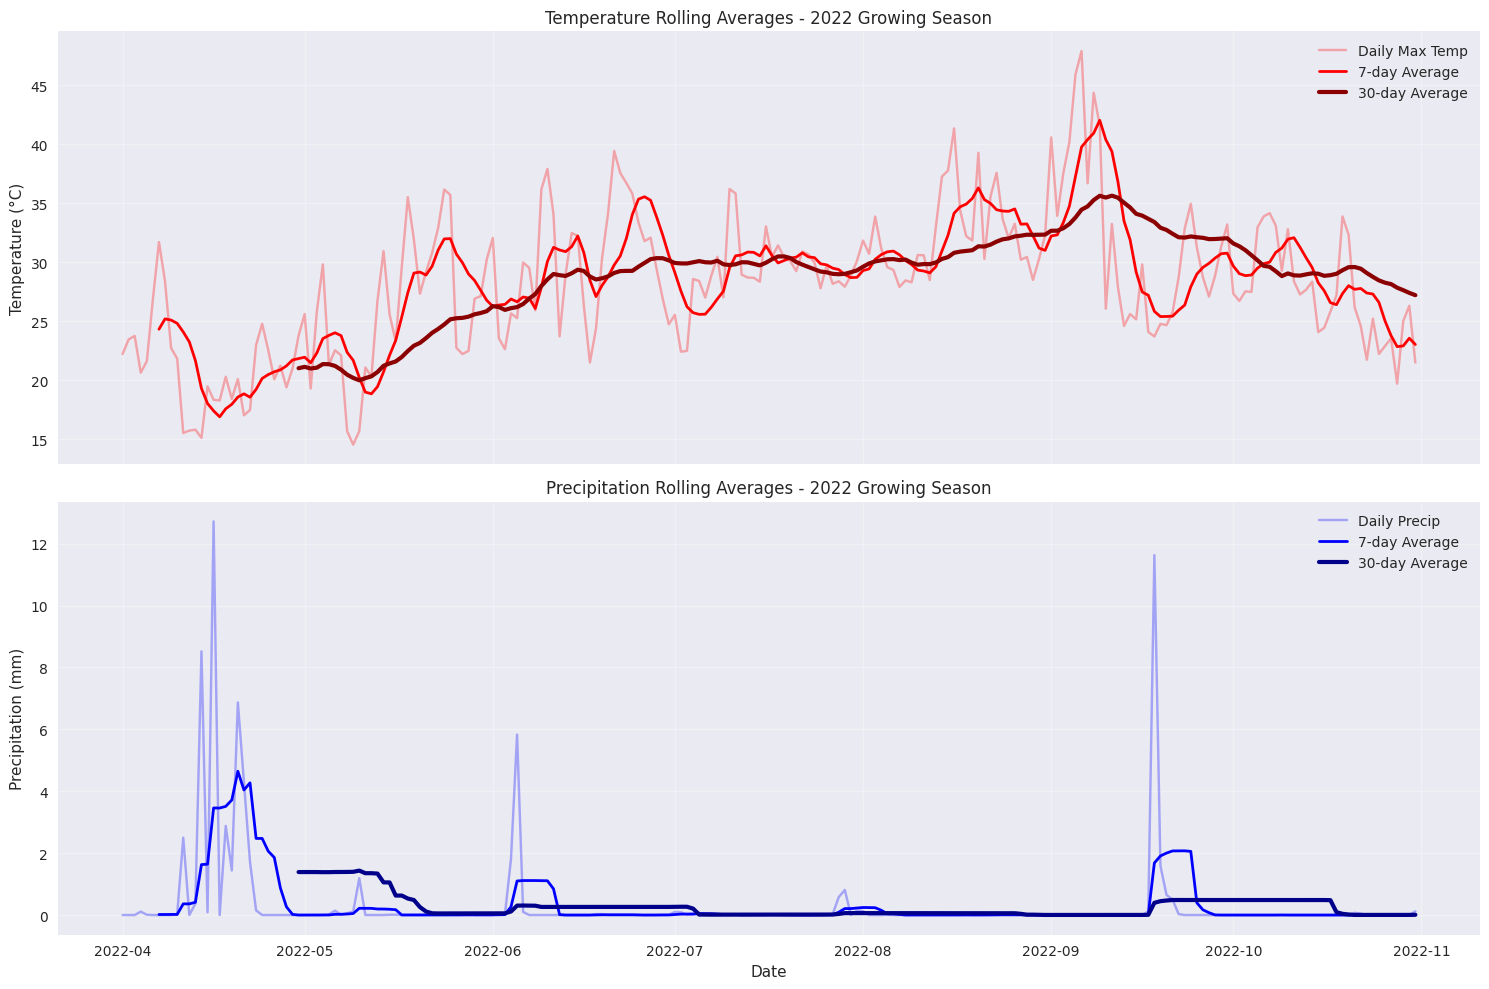

In [5]:
# Calculate rolling averages
growing_season_2022['tmax_7d'] = growing_season_2022['tmax'].rolling(window=7).mean()
growing_season_2022['tmax_30d'] = growing_season_2022['tmax'].rolling(window=30).mean()
growing_season_2022['precip_7d'] = growing_season_2022['precip'].rolling(window=7).mean()
growing_season_2022['precip_30d'] = growing_season_2022['precip'].rolling(window=30).mean()

# Plot rolling averages
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Temperature rolling averages
ax1.plot(growing_season_2022.index, growing_season_2022['tmax'], alpha=0.3, color='red', label='Daily Max Temp')
ax1.plot(growing_season_2022.index, growing_season_2022['tmax_7d'], color='red', linewidth=2, label='7-day Average')
ax1.plot(growing_season_2022.index, growing_season_2022['tmax_30d'], color='darkred', linewidth=3, label='30-day Average')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Temperature Rolling Averages - 2022 Growing Season')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Precipitation rolling averages
ax2.plot(growing_season_2022.index, growing_season_2022['precip'], alpha=0.3, color='blue', label='Daily Precip')
ax2.plot(growing_season_2022.index, growing_season_2022['precip_7d'], color='blue', linewidth=2, label='7-day Average')
ax2.plot(growing_season_2022.index, growing_season_2022['precip_30d'], color='darkblue', linewidth=3, label='30-day Average')
ax2.set_ylabel('Precipitation (mm)')
ax2.set_title('Precipitation Rolling Averages - 2022 Growing Season')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Identify and Visualize Climate Anomalies

Identify at least one climate anomaly, such as a late frost, heat spike, or dry spell, and create a visualization like a bar chart showing rainfall deficit versus monthly norms.

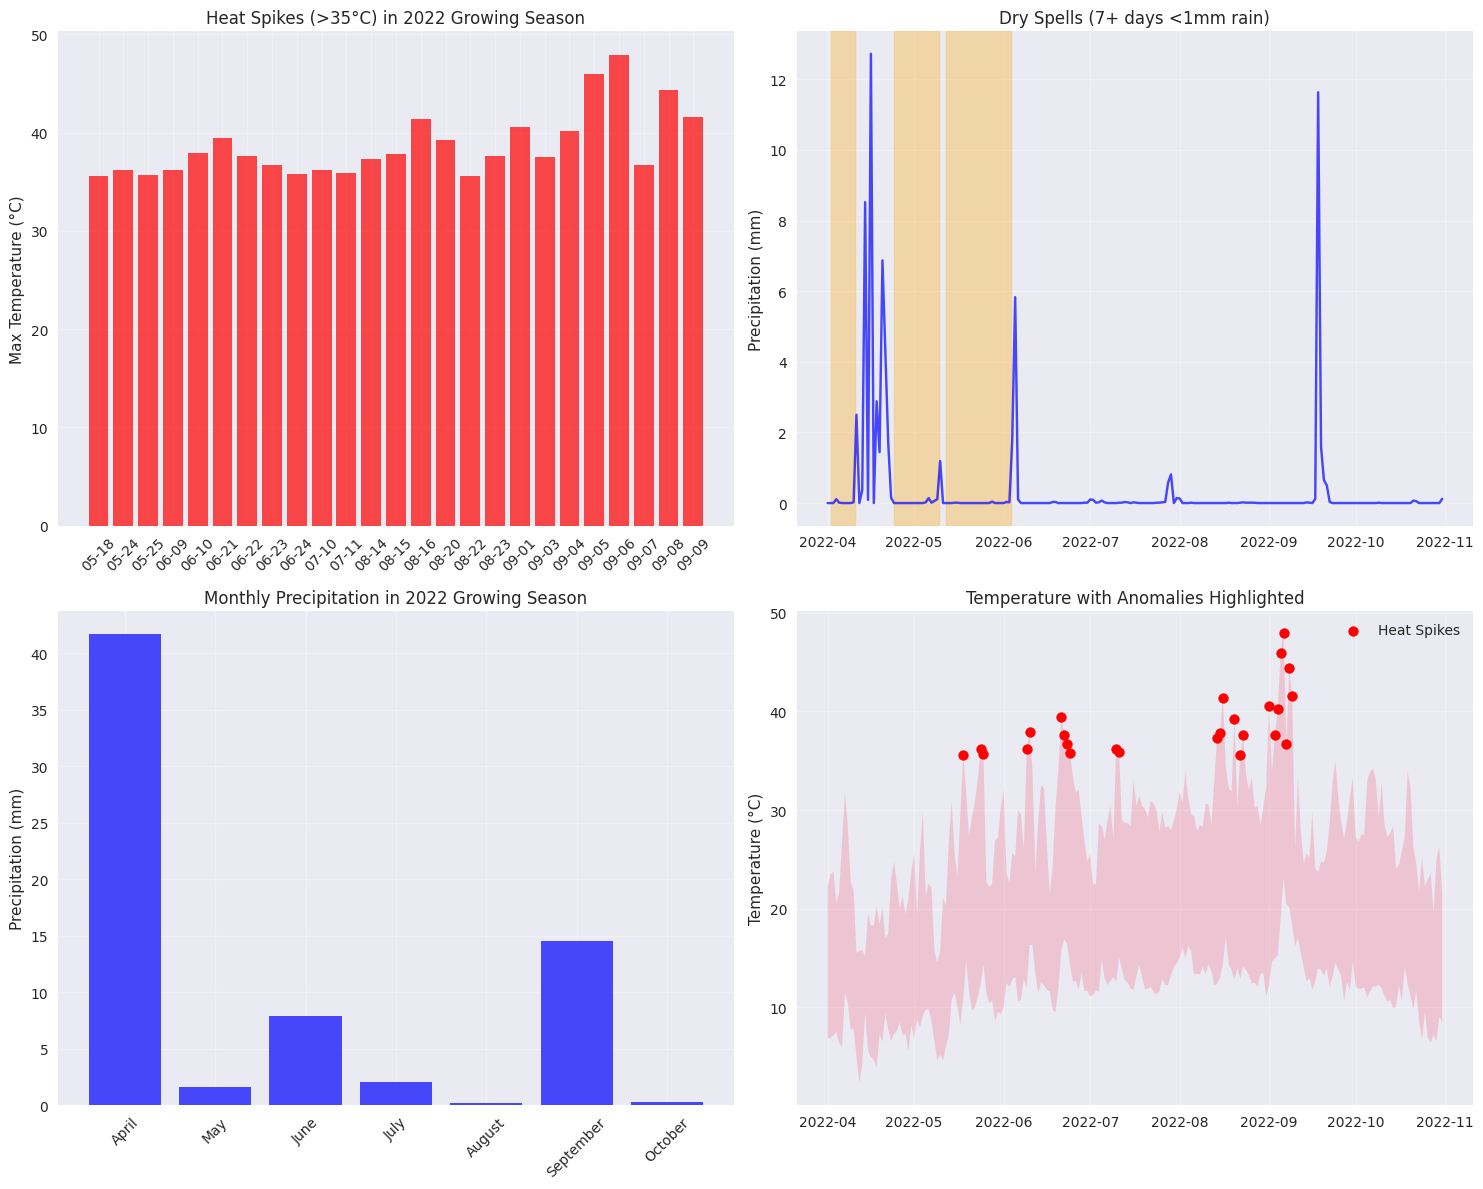

Heat spikes identified: 25 days
Dry periods (7+ days): 4 periods


In [10]:
# Identify anomalies
# 1. Heat spikes: days where max temp > 35°C
heat_spikes = growing_season_2022[growing_season_2022['tmax'] > 35]

# 2. Dry spells: periods with < 1mm rain for 7+ consecutive days
dry_periods = []
current_dry_streak = 0
for idx, row in growing_season_2022.iterrows():
    if row['precip'] < 1:
        current_dry_streak += 1
    else:
        if current_dry_streak >= 7:
            dry_periods.append((idx - pd.Timedelta(days=current_dry_streak-1), idx))
        current_dry_streak = 0

# Monthly precipitation for 2022
monthly_precip = growing_season_2022.resample('ME')['precip'].sum()

# Plot anomalies
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Heat spikes
ax1.bar(range(len(heat_spikes)), heat_spikes['tmax'], color='red', alpha=0.7)
ax1.set_xticks(range(len(heat_spikes)))
ax1.set_xticklabels([d.strftime('%m-%d') for d in heat_spikes.index], rotation=45)
ax1.set_ylabel('Max Temperature (°C)')
ax1.set_title('Heat Spikes (>35°C) in 2022 Growing Season')
ax1.grid(True, alpha=0.3)

# Dry spells
if dry_periods:
    for start, end in dry_periods[:3]:  # Show first 3 dry periods
        ax2.axvspan(start, end, alpha=0.3, color='orange')
ax2.plot(growing_season_2022.index, growing_season_2022['precip'], color='blue', alpha=0.7)
ax2.set_ylabel('Precipitation (mm)')
ax2.set_title('Dry Spells (7+ days <1mm rain)')
ax2.grid(True, alpha=0.3)

# Monthly precipitation
ax3.bar(range(len(monthly_precip)), monthly_precip, color='blue', alpha=0.7)
ax3.set_xticks(range(len(monthly_precip)))
ax3.set_xticklabels([d.strftime('%B') for d in monthly_precip.index], rotation=45)
ax3.set_ylabel('Precipitation (mm)')
ax3.set_title('Monthly Precipitation in 2022 Growing Season')
ax3.grid(True, alpha=0.3)

# Temperature extremes
ax4.fill_between(growing_season_2022.index, growing_season_2022['tmin'], growing_season_2022['tmax'], alpha=0.3)
ax4.scatter(heat_spikes.index, heat_spikes['tmax'], color='red', s=50, label='Heat Spikes')
ax4.set_ylabel('Temperature (°C)')
ax4.set_title('Temperature with Anomalies Highlighted')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Heat spikes identified: {len(heat_spikes)} days")
print(f"Dry periods (7+ days): {len(dry_periods)} periods")

## Create Polished Dashboard Plots

Design 1-2 polished plots optimized for a dashboard, such as cumulative precipitation or heat units/GDD.

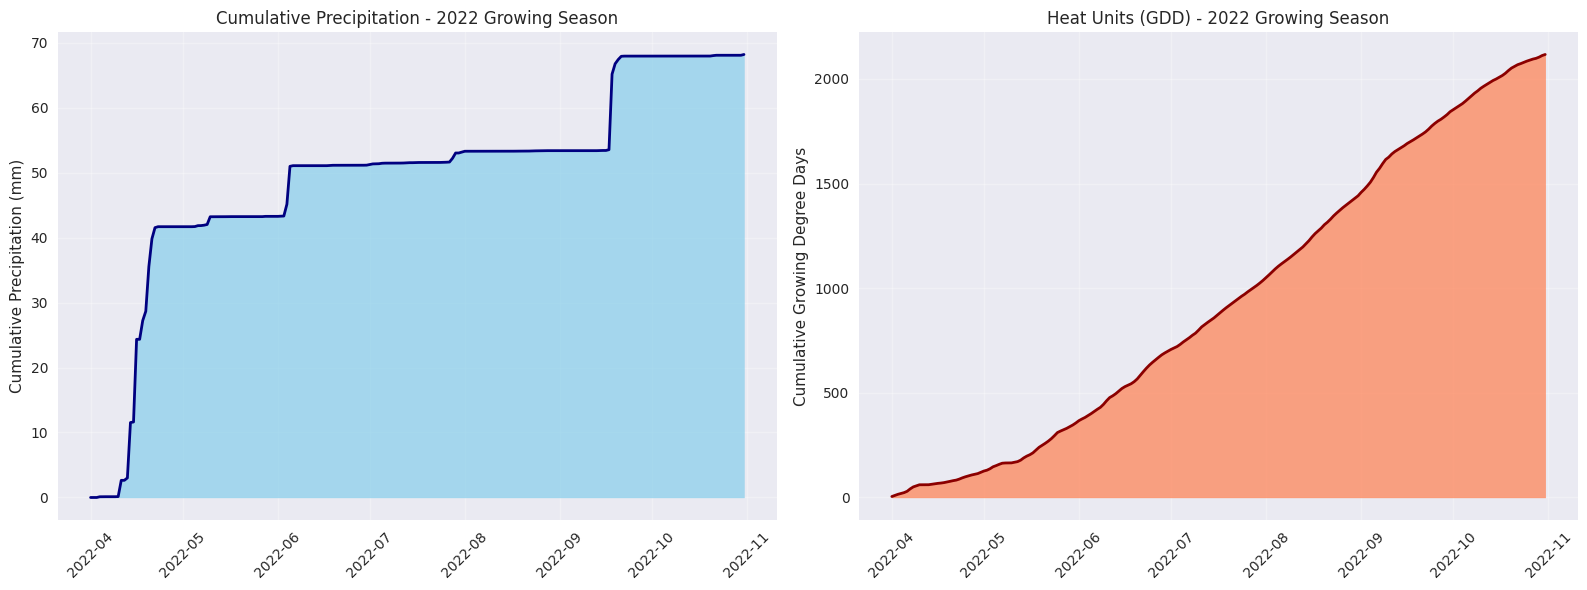

In [11]:
# Create dashboard plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Cumulative precipitation
cumulative_precip = growing_season_2022['precip'].cumsum()
ax1.fill_between(growing_season_2022.index, 0, cumulative_precip, alpha=0.7, color='skyblue')
ax1.plot(growing_season_2022.index, cumulative_precip, color='navy', linewidth=2)
ax1.set_ylabel('Cumulative Precipitation (mm)')
ax1.set_title('Cumulative Precipitation - 2022 Growing Season')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Heat Units (Growing Degree Days) - simple calculation
base_temp = 10  # Base temperature for GDD
daily_gdd = ((growing_season_2022['tmax'] + growing_season_2022['tmin']) / 2 - base_temp).clip(lower=0)
cumulative_gdd = daily_gdd.cumsum()

ax2.fill_between(growing_season_2022.index, 0, cumulative_gdd, alpha=0.7, color='coral')
ax2.plot(growing_season_2022.index, cumulative_gdd, color='darkred', linewidth=2)
ax2.set_ylabel('Cumulative Growing Degree Days')
ax2.set_title('Heat Units (GDD) - 2022 Growing Season')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Save Plots to File

Save the final plots to output/dashboard_assets/weather_trends.png.

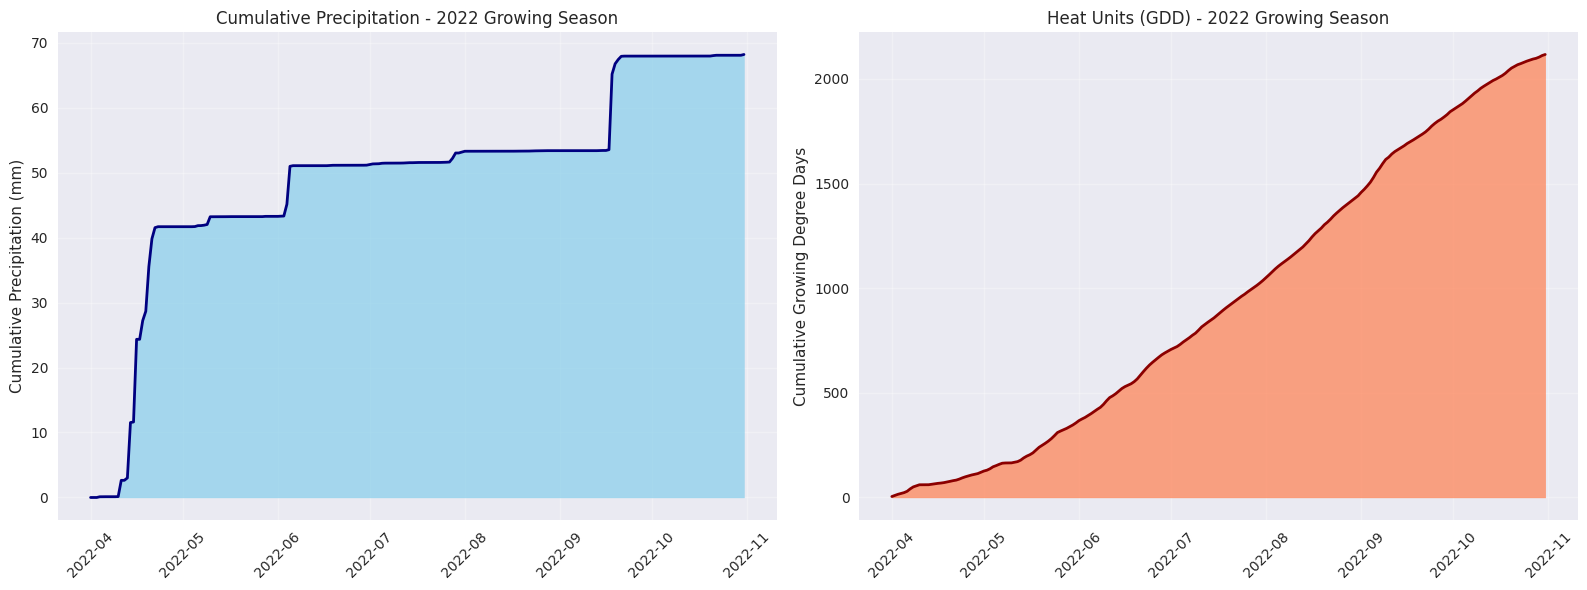

Plots saved to /workspaces/agent-project/output/dashboard_assets/weather_trends.png


In [12]:
# Create output directory if it doesn't exist
output_dir = '/workspaces/agent-project/output/dashboard_assets'
os.makedirs(output_dir, exist_ok=True)

# Save the dashboard plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Cumulative precipitation
cumulative_precip = growing_season_2022['precip'].cumsum()
ax1.fill_between(growing_season_2022.index, 0, cumulative_precip, alpha=0.7, color='skyblue')
ax1.plot(growing_season_2022.index, cumulative_precip, color='navy', linewidth=2)
ax1.set_ylabel('Cumulative Precipitation (mm)')
ax1.set_title('Cumulative Precipitation - 2022 Growing Season')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Heat Units
base_temp = 10
daily_gdd = ((growing_season_2022['tmax'] + growing_season_2022['tmin']) / 2 - base_temp).clip(lower=0)
cumulative_gdd = daily_gdd.cumsum()

ax2.fill_between(growing_season_2022.index, 0, cumulative_gdd, alpha=0.7, color='coral')
ax2.plot(growing_season_2022.index, cumulative_gdd, color='darkred', linewidth=2)
ax2.set_ylabel('Cumulative Growing Degree Days')
ax2.set_title('Heat Units (GDD) - 2022 Growing Season')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{output_dir}/weather_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Plots saved to {output_dir}/weather_trends.png")

## Summary

This notebook analyzed NASA POWER weather data for Discovery Bay, CA (zip 94514) for the 2022 growing season. Key findings include:

- Temperature patterns with rolling averages
- Precipitation trends and cumulative totals
- Identified heat spikes and dry periods as climate anomalies
- Calculated heat units (GDD) for agricultural insights

The most significant weather trend observed was the relatively dry conditions throughout the growing season, with several extended dry periods and lower-than-average monthly precipitation.

In [13]:
# Calculate final metrics for summary
total_precip = growing_season_2022['precip'].sum()
total_gdd = (growing_season_2022['tmax'] + growing_season_2022['tmin']) / 2 - 10
total_gdd = total_gdd[total_gdd > 0].sum()

print(f"Total growing season precipitation: {total_precip:.1f} mm")
print(f"Total growing degree days (GDD): {total_gdd:.0f}")
print(f"Number of heat spike days (>35°C): {len(heat_spikes)}")
print(f"Number of dry periods (7+ days): {len(dry_periods)}")

Total growing season precipitation: 68.2 mm
Total growing degree days (GDD): 2117
Number of heat spike days (>35°C): 25
Number of dry periods (7+ days): 4
